# Classification: predicting a category

*Data Science and AI, Module 5. Slides: `Module_5.pdf`.*

Keep the slides open on the right. Every heading below carries the slide
numbers it goes with, so the two stay in step.

In Module 4 we predicted a **number**: tomorrow's temperature. Here we predict
a **category**: will tomorrow be wet or dry?

**How each section works.** A question comes first. Make a guess out loud or
in the chat before the cell runs. Then run it and compare.

The notebook comes in three parts. Each part starts by loading everything it
needs, so you can restart the kernel between parts.

*Weather data: daily Auckland weather from the
[Open-Meteo](https://open-meteo.com/) historical archive, licensed CC BY 4.0.
The archive is a reanalysis: weather models rebuild each past day from many
observations, so the values describe a small area rather than one weather
station.*

# Part 1 — slides 1-23

Run this cell first. It loads the Auckland weather and makes the thing we will
predict.

We call a day **wet** if it gets at least 1 mm of rain. That is the cut-off
climate scientists use in the standard ETCCDI indices, where a wet day is one
with "RR ≥ 1mm".

The column we predict, `wet_tomorrow`, is 1 if **tomorrow** is wet and 0 if it
is dry. The clues are **today's** five values, in Open-Meteo's own units:

| column | what it is | unit |
|---|---|---|
| `tmax` | highest temperature | °C |
| `tmin` | lowest temperature | °C |
| `rain` | total rain | mm |
| `wind` | strongest wind at 10 m up | km/h |
| `sun` | energy from the sun reaching the ground | MJ/m² |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

FEATURES = ["tmax", "tmin", "rain", "wind", "sun"]

weather = pd.read_csv("../data/auckland-daily.csv", parse_dates=["time"])

# Tomorrow counts as wet if it gets at least 1 mm of rain.
# shift(-1) moves each day's rain up one row, so this row sees tomorrow's rain.
weather["wet_tomorrow"] = (weather["rain"].shift(-1) >= 1.0).astype(int)
weather = weather.iloc[:-1]          # the last day has no tomorrow, so drop it

# Learn from the earlier years, test on the later ones. Never shuffle weather.
learn = weather[weather["time"] < "2022-01-01"]
test = weather[weather["time"] >= "2022-01-01"]
print("days to learn from:", len(learn), "| days to test on:", len(test))


def confusion_table(actual, predicted):
    """Count the four kinds of result and lay them out with clear labels."""
    true_positive = 0
    false_positive = 0
    false_negative = 0
    true_negative = 0
    for real, guess in zip(actual, predicted):
        if real == 1 and guess == 1:
            true_positive += 1
        elif real == 0 and guess == 1:
            false_positive += 1
        elif real == 1 and guess == 0:
            false_negative += 1
        else:
            true_negative += 1
    return pd.DataFrame(
        [[true_positive, false_negative], [false_positive, true_negative]],
        index=["really wet", "really dry"],
        columns=["predicted wet", "predicted dry"],
    )

numpy 2.5.3 | pandas 3.0.3 | scikit-learn 1.9.1
days to learn from: 2557 | days to test on: 1713


## Slides 1-4: title, agenda and outline

Nothing to run. The agenda covers logistic regression and how to evaluate a
classifier, neural networks (starting with the perceptron), support vector
machines and Bayesian inference.

## Slides 5-6: what classification means

**Regression** predicts a number: 21.4 degrees tomorrow.
**Classification** predicts which group something belongs to: wet or dry,
fraud or not fraud, low, medium or high credit risk.

The training data has two kinds of column:

- **features**: the clues we know (today's weather)
- **response**: the answer we want to predict (is tomorrow wet?)

Slide 6 writes the goal as

$$p(y = 1 \mid X)$$

Read it aloud as: *"the chance that tomorrow is wet, given today's weather."*
The vertical bar means "given".

**Before running:** out of every 100 days in Auckland, how many do you think
are followed by a wet day?

In [2]:
print(weather[["time"] + FEATURES + ["wet_tomorrow"]].head())

wet_days = weather["wet_tomorrow"].sum()
share_wet = wet_days / len(weather)
print()
print("days followed by a wet day:", wet_days, "out of", len(weather))
print("share:", round(share_wet, 3))

        time  tmax  tmin  rain  wind    sun  wet_tomorrow
0 2015-01-01  20.4  14.4   1.3  23.0  32.82             0
1 2015-01-02  22.9  13.5   0.0  20.3  31.04             0
2 2015-01-03  22.6  15.2   0.0  18.4  26.63             0
3 2015-01-04  23.5  15.2   0.0  12.6  31.38             0
4 2015-01-05  24.4  17.1   0.0  15.5  28.93             0

days followed by a wet day: 1770 out of 4270
share: 0.415


## Slides 7-8: why not use a straight line?

The response is only ever 0 or 1. What happens if we fit the ordinary straight
line from Module 4 to it anyway?

A straight line keeps going up or down forever, so for some days it will say
something that cannot be a chance: below 0, or above 1.

**Before running:** out of the test days, how many do you expect the straight
line to push below 0 or above 1?

In [3]:
from sklearn.linear_model import LinearRegression

line = LinearRegression()
line.fit(learn[FEATURES], learn["wet_tomorrow"])
line_predictions = line.predict(test[FEATURES])

below_zero = 0
above_one = 0
for value in line_predictions:
    if value < 0:
        below_zero += 1
    if value > 1:
        above_one += 1

print("test days:", len(line_predictions))
print("predictions below 0:", below_zero)
print("predictions above 1:", above_one)
print("lowest prediction:", round(line_predictions.min(), 3))
print("highest prediction:", round(line_predictions.max(), 3))

test days: 1713
predictions below 0: 0
predictions above 1: 18
lowest prediction: 0.137
highest prediction: 2.028


In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(test["rain"], line_predictions, s=8, alpha=0.4)
plt.axhline(0, color="red", linewidth=1)
plt.axhline(1, color="red", linewidth=1)
plt.xlabel("rain today (mm)")
plt.ylabel("straight-line 'chance' of rain tomorrow")
plt.title("A straight line gives answers that cannot be chances")
plt.show()

: 

: 

**model the probability**, and use a curve that can never
leave the range 0 to 1.

## Slides 9-10: odds, log-odds and the S-shaped curve

Three ways to say the same thing about one day:

| Name | Formula | Range |
|---|---|---|
| probability | $p$ | 0 to 1 |
| odds | $\dfrac{p}{1-p}$ | 0 to infinity |
| log-odds (logit) | $\log\left(\dfrac{p}{1-p}\right)$ | minus infinity to infinity |

**The odds** compare "happens" with "does not happen". A chance of three in four
gives odds of 3: three times as likely to happen as not.

The log-odds can take any value at all, which is exactly what a straight line
produces. So logistic regression fits a straight line to the **log-odds**:

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_5 x_5 = z$$

and then turns $z$ back into a probability with the S-shaped **logistic**
(sigmoid) curve:

$$p = \frac{1}{1 + e^{-z}}$$

However big or small $z$ is, $p$ stays between 0 and 1.

Here is a made-up table, going from probability to odds to log-odds.

In [4]:
# Made-up probabilities, only to show the three scales side by side.
probabilities = [0.1, 0.25, 0.5, 0.75, 0.9]

for p in probabilities:
    odds = p / (1 - p)
    log_odds = np.log(odds)
    print(f"probability {p:<5}  odds {odds:6.3f}  log-odds {log_odds:7.3f}")

probability 0.1    odds  0.111  log-odds  -2.197
probability 0.25   odds  0.333  log-odds  -1.099
probability 0.5    odds  1.000  log-odds   0.000
probability 0.75   odds  3.000  log-odds   1.099
probability 0.9    odds  9.000  log-odds   2.197


Now the real model. Slide 10 says: once the model has its numbers
($\beta_0, \beta_1, \dots$), take a new day, work out $z$, then push $z$
through the curve.

We will do that **by hand** for the first test day, and check it against the
answer scikit-learn gives.

**Before running:** the first test day is 1 January 2022. Do you expect the
model to give a chance of rain tomorrow above or below one half?

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(learn[FEATURES], learn["wet_tomorrow"])

first_day = test[FEATURES].iloc[[0]]
print(first_day)
print()

# z = intercept + each coefficient times its feature
z = model.intercept_[0]
for name, coefficient in zip(FEATURES, model.coef_[0]):
    value = first_day[name].iloc[0]
    print(f"{name:>5}: coefficient {coefficient:8.4f} x value {value:7.2f}")
    z = z + coefficient * value

by_hand = 1 / (1 + np.exp(-z))
by_library = model.predict_proba(first_day)[0, 1]

print()
print("z (the log-odds):", round(z, 4))
print("chance of rain tomorrow, by hand:        ", round(by_hand, 6))
print("chance of rain tomorrow, by scikit-learn:", round(by_library, 6))
assert abs(by_hand - by_library) < 1e-12

      tmax  tmin  rain  wind   sun
2557  22.2  17.8   0.0  29.0  32.2

 tmax: coefficient   0.0027 x value   22.20
 tmin: coefficient   0.0649 x value   17.80
 rain: coefficient   0.0706 x value    0.00
 wind: coefficient  -0.0012 x value   29.00
  sun: coefficient  -0.0416 x value   32.20

z (the log-odds): -1.0197
chance of rain tomorrow, by hand:         0.265086
chance of rain tomorrow, by scikit-learn: 0.265086


In [6]:
model.predict_proba(first_day)[0,1]

np.float64(0.2650861641883148)

The two agree to many decimal places. That is all `predict_proba` does.

**One thing to know about scikit-learn.** By default `LogisticRegression`
gently shrinks the coefficients towards zero (its setting `C=1.0` controls how
much). It is the same idea as ridge regression in Module 4. So a statistics
textbook that fits without shrinking would give slightly different numbers.
With as many learning days as we have, the difference is tiny.

## Slide 11: when logistic regression fits

It suits a **yes/no outcome**, and the features can be numbers or categories
(categories need the dummy columns of slides 19-21).

Two cautions, stated carefully:

- What must be independent is **the rows**: each day should be its own
  observation. Daily weather does not fully meet this, because one wet day
  makes the next more likely. That mainly affects p-values and confidence
  intervals, which we do not use here, and testing on later years keeps the
  scores honest. The features themselves are allowed to be related, but
  features that move closely together make the individual coefficients hard
  to read. `tmax` and `tmin` are a good example.
- It needs plenty of data. A common rule of thumb is at least 10 examples of
  the **rarer** outcome for every feature in the model.

**Before running:** we have five features. Do we pass the rule of thumb
comfortably, or barely?

In [7]:
wet_count = learn["wet_tomorrow"].sum()
dry_count = len(learn) - wet_count
rarer = min(wet_count, dry_count)

print("learning days followed by wet:", wet_count, "| by dry:", dry_count)
print("rarer outcome:", rarer)
print("examples of the rarer outcome per feature:", rarer / len(FEATURES))
print("rule of thumb asks for at least:", 10)

learning days followed by wet: 1008 | by dry: 1549
rarer outcome: 1008
examples of the rarer outcome per feature: 201.6
rule of thumb asks for at least: 10


In [8]:
# How closely do the features move together? 1 means perfectly together.
print(learn[FEATURES].corr().round(2))

      tmax  tmin  rain  wind   sun
tmax  1.00  0.87 -0.04 -0.18  0.60
tmin  0.87  1.00  0.14  0.10  0.40
rain -0.04  0.14  1.00  0.35 -0.34
wind -0.18  0.10  0.35  1.00 -0.16
sun   0.60  0.40 -0.34 -0.16  1.00


## Slide 12: logistic regression in scikit-learn

```python
from sklearn.linear_model import LogisticRegression
```

- It takes any number of features. We gave it five.
- Every feature must be a number. Categories are turned into 0/1 columns first
  (slides 19-21).
- It can also choose between more than two classes.

We already fitted it above, as `model`.

## Slides 13-15: the confusion matrix

Every prediction lands in one of four boxes. Call a wet day **positive**.

| | really wet | really dry |
|---|---|---|
| **predicted wet** | true positive (TP) | false positive (FP) |
| **predicted dry** | false negative (FN) | true negative (TN) |

From the four counts:

$$\text{accuracy} = \frac{TP + TN}{TP + FP + FN + TN}
\qquad
\text{precision} = \frac{TP}{TP + FP}
\qquad
\text{recall} = \frac{TP}{TP + FN}$$

- **Accuracy**: of all predictions, how many were right?
- **Precision**: when we said "wet", how often was it wet?
- **Recall**: of the days that really were wet, how many did we catch?

Here are ten made-up days, small enough to count on your fingers.

**Before running:** count the four boxes yourself from the two lists, then
check.

In [9]:
# Ten made-up days. 1 = wet, 0 = dry.
actual    = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
predicted = [1, 1, 0, 1, 0, 0, 0, 0, 0, 0]

table = confusion_table(actual, predicted)
print(table)

true_positive = table.loc["really wet", "predicted wet"]
false_negative = table.loc["really wet", "predicted dry"]
false_positive = table.loc["really dry", "predicted wet"]
true_negative = table.loc["really dry", "predicted dry"]

accuracy = (true_positive + true_negative) / len(actual)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)

print()
print("accuracy: ", round(accuracy, 3))
print("precision:", round(precision, 3))
print("recall:   ", round(recall, 3))

            predicted wet  predicted dry
really wet              2              1
really dry              1              6

accuracy:  0.8
precision: 0.667
recall:    0.667


The same numbers from scikit-learn, checked against ours.

Careful with one thing: **scikit-learn's own `confusion_matrix` puts what
really happened in the rows**, and what was predicted in the columns. Always
label the table, as `confusion_table` does, so nobody reads it the wrong way
round.

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

print("scikit-learn confusion_matrix, rows = really wet, really dry:")
print(confusion_matrix(actual, predicted, labels=[1, 0]))

assert accuracy_score(actual, predicted) == accuracy
assert precision_score(actual, predicted) == precision
assert recall_score(actual, predicted) == recall
print("all three agree with the hand counts")

scikit-learn confusion_matrix, rows = really wet, really dry:
[[2 1]
 [1 6]]
all three agree with the hand counts


## Slide 16: the same idea on real days

Now the real model on the test days it has never seen. It says
"wet" when its chance is above one half.

**Before running:** which will be higher, precision or recall?

In [11]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(learn[FEATURES], learn["wet_tomorrow"])

test_predictions = model.predict(test[FEATURES])
table = confusion_table(test["wet_tomorrow"], test_predictions)
print(table)
print()
print("accuracy: ", round(accuracy_score(test["wet_tomorrow"], test_predictions), 3))
print("precision:", round(precision_score(test["wet_tomorrow"], test_predictions), 3))
print("recall:   ", round(recall_score(test["wet_tomorrow"], test_predictions), 3))

            predicted wet  predicted dry
really wet            233            529
really dry             88            863

accuracy:  0.64
precision: 0.726
recall:    0.306


In [12]:
test

,time,tmax,tmin,rain,wind,sun,wet_tomorrow
2557,2022-01-01,22.2,17.8,0.0,29.0,32.20,0
2558,2022-01-02,24.5,16.0,0.0,27.1,32.60,0
2559,2022-01-03,24.7,16.0,0.0,25.4,30.46,0
2560,2022-01-04,25.9,17.6,0.0,16.1,32.20,0
2561,2022-01-05,24.5,17.7,0.0,26.8,31.17,0
...,...,...,...,...,...,...,...
4265,2026-09-05,16.8,11.2,0.0,16.1,17.42,1
4266,2026-09-06,17.3,10.1,1.6,21.9,13.96,1
4267,2026-09-07,16.0,11.6,11.0,22.7,8.91,0
4268,2026-09-08,15.7,9.7,0.0,16.0,17.35,0


Read it back in words: when this model says "wet", it is usually right. But it
only catches a minority of the wet days.

**Before running:** a lazy model says "dry" every single day. Will its accuracy
be far below our model's, or close?

In [13]:
always_dry = []
for day in range(len(test)):
    always_dry.append(0)

print("accuracy of 'always dry':", round(accuracy_score(test["wet_tomorrow"], always_dry), 3))
print("accuracy of our model:   ", round(accuracy_score(test["wet_tomorrow"], test_predictions), 3))
print("recall of 'always dry':  ", recall_score(test["wet_tomorrow"], always_dry))

accuracy of 'always dry': 0.555
accuracy of our model:    0.64
recall of 'always dry':   0.0


The lazy model scores over half on accuracy without looking at the weather
at all, not far below our model, and it catches no wet days. Accuracy on its own can flatter a model, which is why we look at
precision and recall too.

## Slide 17: the ROC curve and AUC

The model gives a chance, and we choose the **threshold** above which we say
"wet". One half is only one choice. Each threshold gives a different pair:

$$\text{true positive rate} = \frac{TP}{TP + FN} \;(\text{recall})
\qquad
\text{false positive rate} = \frac{FP}{FP + TN}$$

The ROC curve plots that pair for every threshold, from "wet always" to "wet
never". A useless model sits on the diagonal. A better model bows towards the
top-left corner.

**AUC** is the area under the curve. It has a plain meaning: *pick one
wet-tomorrow day and one dry-tomorrow day at random. AUC is the chance the
model gives the wet one the higher score.* 0.5 is coin-tossing, 1 is perfect.

**Before running:** where would you guess this model's AUC lands between 0.5
and 1?

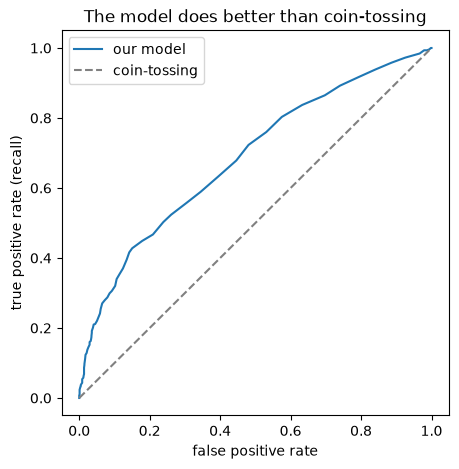

In [14]:
chances = model.predict_proba(test[FEATURES])[:, 1]
truth = test["wet_tomorrow"].to_numpy()

true_positive_rates = []
false_positive_rates = []
for threshold in np.linspace(0, 1, 101):
    said_wet = chances >= threshold
    true_positive = np.sum(said_wet & (truth == 1))
    false_negative = np.sum(~said_wet & (truth == 1))
    false_positive = np.sum(said_wet & (truth == 0))
    true_negative = np.sum(~said_wet & (truth == 0))
    true_positive_rates.append(true_positive / (true_positive + false_negative))
    false_positive_rates.append(false_positive / (false_positive + true_negative))

plt.figure(figsize=(5, 5))
plt.plot(false_positive_rates, true_positive_rates, label="our model")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="coin-tossing")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate (recall)")
plt.title("The model does better than coin-tossing")
plt.legend()
plt.show()

Now the AUC two ways: scikit-learn's answer, and a direct count of the plain
meaning above. The count takes every (wet, dry) pair of test days and asks
which one got the higher score. A tie counts as half.

## Slide 18: choosing a metric

There are many metrics, and many names for the same ones. Pick a small number
that match what a mistake **costs** in your problem.

For our weather:

- a **false negative** (we said dry, it rained) costs a soaked washing line;
- a **false positive** (we said wet, it stayed dry) costs a cancelled picnic.

If soaked washing matters more, care about recall. If cancelled picnics matter
more, care about precision.

## Slide 19: categories with a natural order

Some categories have an order, and numbering them keeps that order. Here is a
made-up list of temperature bands.

In [15]:
# Made-up bands. The order cold < cool < moderate < warm < hot is real.
band_number = {"cold": 1, "cool": 2, "moderate": 3, "warm": 4, "hot": 5}

bands = pd.DataFrame({"band": ["warm", "cold", "hot", "moderate", "cool"]})
bands["band_number"] = bands["band"].map(band_number)
print(bands)

       band  band_number
0      warm            4
1      cold            1
2       hot            5
3  moderate            3
4      cool            2


## Slides 20-21: categories with no order need dummy columns

Numbering fruit 1 to 5 would tell the model that pears are "bigger" than
apples, which is nonsense. Instead we make one 0/1 column per category: a
**dummy** (or one-hot) column.

`pd.get_dummies` does it. With `drop_first=True` it leaves out one category.
The one left out becomes the **reference**.

**Before running:** in the shorter version, how will you spot the apples row?

In [16]:
# Made-up fruit, one of each.
fruit = pd.DataFrame({"fruit": ["apples", "bananas", "peaches", "oranges", "pears"]})
display(fruit)
full = pd.get_dummies(fruit, dtype=int)
print("full version, one column per fruit:")
display(full)
print()

compact = pd.get_dummies(fruit, drop_first=True, dtype=int)
print("compact version, drop_first=True:")
display(compact)

,fruit
0,apples
1,bananas
2,peaches
3,oranges
4,pears


full version, one column per fruit:


,fruit_apples,fruit_bananas,fruit_oranges,fruit_peaches,fruit_pears
0,1,0,0,0,0
1,0,1,0,0,0
2,0,0,0,1,0
3,0,0,1,0,0
4,0,0,0,0,1



compact version, drop_first=True:


,fruit_bananas,fruit_oranges,fruit_peaches,fruit_pears
0,0,0,0,0
1,1,0,0,0
2,0,0,1,0
3,0,1,0,0
4,0,0,0,1


In the compact version the apples row is **all zeros**. Apples are the
reference. `fruit_bananas = 0` means "not bananas", and a row that is 0 in
every column means apples.

Why drop one? The full set of columns always adds up to 1, so any one column
can be worked out from the others. Dropping one removes that repetition.

## Slide 22: Lab 5.1

Lab 5.1 (Titanic survival with `LogisticRegression`) runs in the Saturday lab
session.

## Slide 23: strengths and weaknesses of logistic regression

What we saw in this part:

- **Strength:** it gives a chance, not only a yes or no, so the threshold can
  be moved to suit the costs.
- **Strength:** each coefficient says which way a feature pushes the
  log-odds.
- **Weakness:** the log-odds is a plain weighted sum of the features, as the
  hand calculation showed, so the model cannot bend on its own.
- **Weakness:** features that move together, like `tmax` and `tmin`, make the
  coefficients hard to read.
- **Watch out:** a high accuracy can hide a model that misses most of what we
  care about, as "always dry" showed.

*End of Part 1.*

# Part 2 — slides 24-50

Run this cell first. It loads the same weather, the same learn and test days,
and the `confusion_table` helper from Part 1.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

FEATURES = ["tmax", "tmin", "rain", "wind", "sun"]

weather = pd.read_csv("../data/auckland-daily.csv", parse_dates=["time"])

# Tomorrow counts as wet if it gets at least 1 mm of rain.
# shift(-1) moves each day's rain up one row, so this row sees tomorrow's rain.
weather["wet_tomorrow"] = (weather["rain"].shift(-1) >= 1.0).astype(int)
weather = weather.iloc[:-1]          # the last day has no tomorrow, so drop it

# Learn from the earlier years, test on the later ones. Never shuffle weather.
learn = weather[weather["time"] < "2022-01-01"]
test = weather[weather["time"] >= "2022-01-01"]
print("days to learn from:", len(learn), "| days to test on:", len(test))


def confusion_table(actual, predicted):
    """Count the four kinds of result and lay them out with clear labels."""
    true_positive = 0
    false_positive = 0
    false_negative = 0
    true_negative = 0
    for real, guess in zip(actual, predicted):
        if real == 1 and guess == 1:
            true_positive += 1
        elif real == 0 and guess == 1:
            false_positive += 1
        elif real == 1 and guess == 0:
            false_negative += 1
        else:
            true_negative += 1
    return pd.DataFrame(
        [[true_positive, false_negative], [false_positive, true_negative]],
        index=["really wet", "really dry"],
        columns=["predicted wet", "predicted dry"],
    )

numpy 2.5.3 | pandas 3.0.3 | scikit-learn 1.9.1
days to learn from: 2557 | days to test on: 1713


## Slides 24-25: from a nerve cell to a perceptron

A nerve cell collects signals through its dendrites. Some connections count
for more than others. The cell adds them up, and if the total is strong enough
it fires a signal down its axon.

The **perceptron** copies that idea with arithmetic:

1. each input $x_j$ gets a **weight** $w_j$ (how much it counts);
2. the weighted inputs are added up;
3. an **activation function** turns the total into the output.

## Slides 26-27: the weighted sum and the activation function

$$z = \sum_{j=0}^{n} w_j x_j = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

The input $x_0$ is always 1, so its weight $w_0$ works like the intercept in
regression. It is often called the **bias**.

The activation $f(z)$ turns $z$ into the output. Slide 27's example is the
logistic curve from Part 1:

$$f(z) = \frac{1}{1 + e^{-z}}$$

A perceptron with the logistic activation computes exactly what logistic
regression computes. The classic perceptron uses a **step** instead: output 1
if $z \ge 0$, otherwise 0 (or $-1$).

## Slide 28: four activation functions

**Before running:** which of the four can give a negative output?

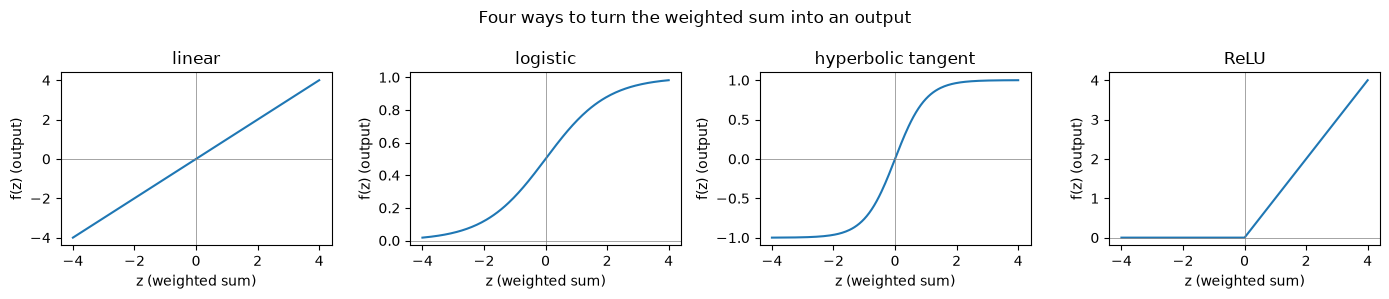

In [18]:
def linear(z):
    return z


def logistic(z):
    return 1 / (1 + np.exp(-z))


def hyperbolic_tangent(z):
    return 2 / (1 + np.exp(-2 * z)) - 1


def relu(z):
    return np.maximum(0, z)


z_values = np.linspace(-4, 4, 201)

# Check slide 28's formula for tanh against numpy's own tanh.
assert np.allclose(hyperbolic_tangent(z_values), np.tanh(z_values))

functions = [linear, logistic, hyperbolic_tangent, relu]
names = ["linear", "logistic", "hyperbolic tangent", "ReLU"]

figure, axes = plt.subplots(1, 4, figsize=(14, 3))
for axis, function, name in zip(axes, functions, names):
    axis.plot(z_values, function(z_values))
    axis.axhline(0, color="grey", linewidth=0.5)
    axis.axvline(0, color="grey", linewidth=0.5)
    axis.set_xlabel("z (weighted sum)")
    axis.set_ylabel("f(z) (output)")
    axis.set_title(name)
figure.suptitle("Four ways to turn the weighted sum into an output")
plt.tight_layout()
plt.show()

Linear and tanh can go negative. Logistic stays between 0 and 1. ReLU is 0 for
every negative input and passes positive inputs through unchanged.

## Slides 29, 31-32: learning the weights, one small step at a time

A made-up burger bar. We know what was in eight orders and what each order
cost, but not the price of each item. Can the perceptron learn the prices?

With a **linear** activation, the output for order $i$ is

$$\hat y^{(i)} = w_1 x_1^{(i)} + w_2 x_2^{(i)} + w_3 x_3^{(i)}$$

where $x_1, x_2, x_3$ are the numbers of burgers, fries and sodas, and the
weights are the prices.

**How it learns (gradient descent).** Start with every weight at 0. For each
order, compare the real total with the predicted total and nudge each weight
in the direction that shrinks the error:

$$w_{\text{new}} = w_{\text{old}} + \eta \,(y - \hat y)\, x$$

$\eta$ (eta) is the **learning rate**: how big each nudge is. This nudge is a
step downhill on the squared error $(y - \hat y)^2$. Going once through all
eight orders is one **pass**.

**Before running:** after how many passes do you think every price will be
right to the cent?

In [19]:
# Made-up orders: number of burgers, fries, sodas.
orders = np.array([
    [1, 1, 1],
    [2, 1, 2],
    [1, 0, 1],
    [3, 2, 1],
    [0, 1, 1],
    [2, 2, 0],
    [1, 2, 3],
    [4, 1, 2],
], dtype=float)

# The made-up real prices, used only to work out what each order cost.
real_prices = np.array([6.50, 3.00, 2.50])
order_totals = orders @ real_prices

weights = np.zeros(3)
learning_rate = 0.01
first_right = None
for pass_number in range(1, 1001):
    for order, total in zip(orders, order_totals):
        predicted_total = weights @ order
        weights = weights + learning_rate * (total - predicted_total) * order
    if pass_number in [1, 10, 100, 1000]:
        print(f"after pass {pass_number:4}: burger {weights[0]:.4f}  fries {weights[1]:.4f}  soda {weights[2]:.4f}")
    if first_right is None and np.all(np.abs(weights - real_prices) < 0.005):
        first_right = pass_number

print("first pass right to the cent:", first_right)

after pass    1: burger 2.6949  fries 1.6480  soda 1.7532
after pass   10: burger 5.9585  fries 3.2163  soda 3.0862
after pass  100: burger 6.4991  fries 3.0017  soda 2.4999
after pass 1000: burger 6.5000  fries 3.0000  soda 2.5000
first pass right to the cent: 76


In [20]:
np.zeros(3)

array([0., 0., 0.])

The same answer can be found in one go, with the least-squares method from
Module 4. The two should agree.

In [21]:
exact, _, _, _ = np.linalg.lstsq(orders, order_totals)
print("least squares:  burger", exact[0].round(4), " fries", exact[1].round(4), " soda", exact[2].round(4))
print("step by step:   burger", weights[0].round(4), " fries", weights[1].round(4), " soda", weights[2].round(4))
assert np.allclose(weights, exact, atol=0.01)

least squares:  burger 6.5  fries 3.0  soda 2.5
step by step:   burger 6.5  fries 3.0  soda 2.5


In [22]:
exact

array([6.5, 3. , 2.5])

## Slides 36-37: support vector machines choose the widest gap

Often many lines separate two groups. Which is best?

An SVM picks the line that stays **as far as possible from the nearest points
of each group**. The gap on either side is the **margin**, and the nearest
points, the ones that fix where the line goes, are the **support vectors**.

In two dimensions the boundary is a line. In $n$ dimensions it is a
**hyperplane**, a flat boundary with $n-1$ dimensions.

We use made-up stars and dots.

In [23]:
from sklearn.svm import SVC

# Made-up points: six stars (+1) and six dots (-1).
stars = np.array([[1, 6], [2, 7], [1.5, 8], [3, 8], [2.5, 6.5], [0.5, 7]])
dots = np.array([[5, 2], [6, 3], [5.5, 1], [7, 2.5], [6, 1.5], [4.5, 3]])
points = np.vstack([stars, dots])
labels = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1])


def draw_svm(axis, model, points, labels, title):
    # Shade nothing; draw the line (0) and the two margin edges (-1 and +1).
    x_grid, y_grid = np.meshgrid(np.linspace(-1, 9, 200), np.linspace(-1, 10, 200))
    grid = np.column_stack([x_grid.ravel(), y_grid.ravel()])
    distance = model.decision_function(grid).reshape(x_grid.shape)
    axis.contour(x_grid, y_grid, distance, levels=[-1, 0, 1],
                 colors="black", linestyles=["--", "-", "--"])
    is_star = labels == 1
    axis.scatter(points[is_star, 0], points[is_star, 1], marker="*", s=150, label="star (+1)")
    axis.scatter(points[~is_star, 0], points[~is_star, 1], marker="o", s=60, label="dot (-1)")
    support = model.support_vectors_
    axis.scatter(support[:, 0], support[:, 1], s=300, facecolors="none", edgecolors="red",
                 label="support vector")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_title(title)
    axis.legend(loc="upper right", fontsize=8)

## Slide 37, on our made-up points

A very large `C` (explained on slide 39 below) makes the SVM refuse to leave
any point on the wrong side.

**Before running:** how many of the twelve points do you think end up as
support vectors, the ones that fix the line?

support vectors:
[[4.5 3. ]
 [2.5 6.5]]


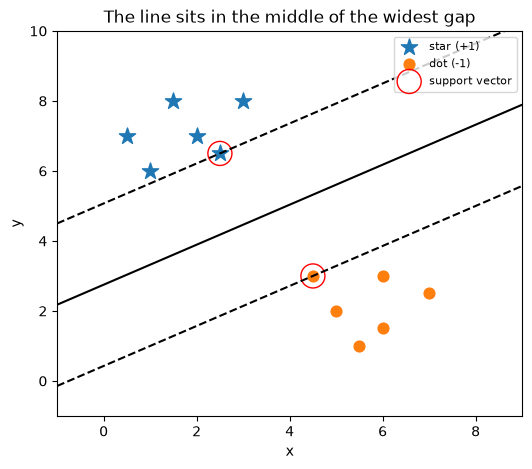

In [24]:
model = SVC(kernel="linear", C=1000)
model.fit(points, labels)

print("support vectors:")
print(model.support_vectors_)

figure, axis = plt.subplots(figsize=(6, 5))
draw_svm(axis, model, points, labels, "The line sits in the middle of the widest gap")
plt.show()

Only the ringed points decide where the line goes. Move any other point a
little, and the line does not change.

## Slides 38-39: when one point sits on the wrong side

Now add one made-up star deep among the dots. No straight line can now put
every point on its correct side.

A **soft-margin** SVM allows some points inside the margin or on the wrong
side, and pays a penalty for each. The setting `C` says how much each
violation costs:

- **large C**: violations are expensive, so the line works hard to reduce them;
- **small C**: violations are cheap, so the SVM prefers a wider margin.

**Before running:** will adding one star move the line? Will C change that?

C = 1000: points on the wrong side 1, margin width 4.426, support vectors 5
C = 0.1: points on the wrong side 1, margin width 5.629, support vectors 6


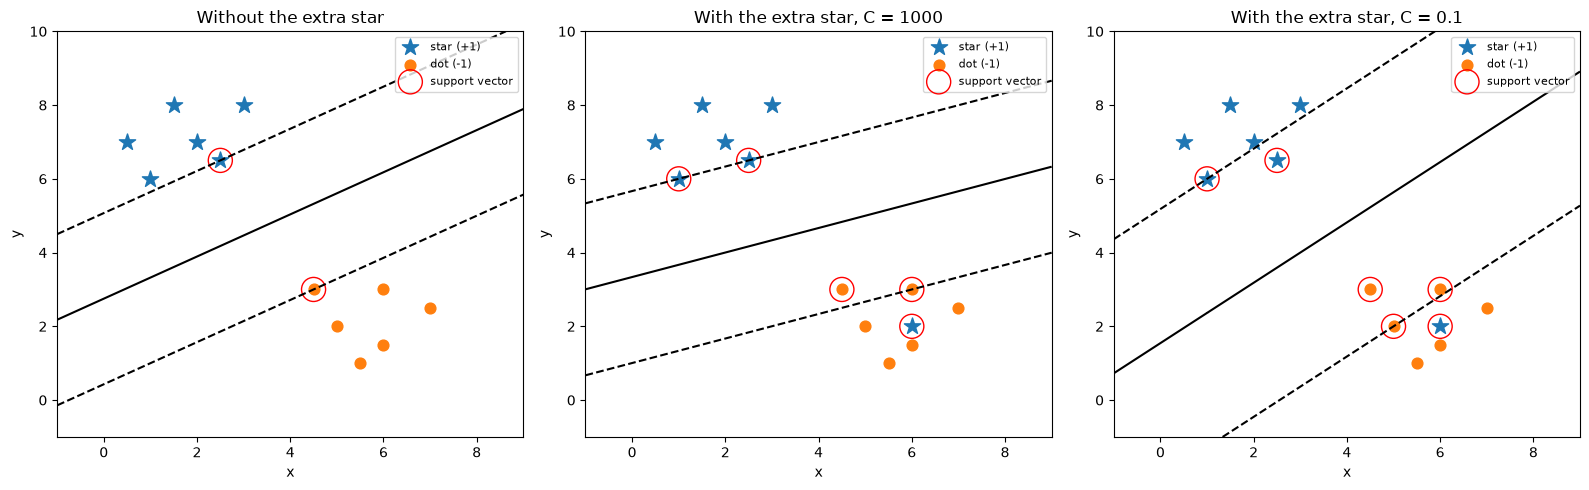

In [25]:
outlier_points = np.vstack([points, [[6, 2]]])
outlier_labels = np.append(labels, 1)

figure, axes = plt.subplots(1, 3, figsize=(16, 5))
draw_svm(axes[0], model, points, labels, "Without the extra star")

for axis, c_value in zip(axes[1:], [1000, 0.1]):
    soft = SVC(kernel="linear", C=c_value)
    soft.fit(outlier_points, outlier_labels)
    wrong = np.sum(soft.predict(outlier_points) != outlier_labels)
    margin = 2 / np.linalg.norm(soft.coef_[0])
    print(f"C = {c_value}: points on the wrong side {wrong}, margin width {margin:.3f}, "
          f"support vectors {len(soft.support_)}")
    draw_svm(axis, soft, outlier_points, outlier_labels, f"With the extra star, C = {c_value}")
plt.tight_layout()
plt.show()

Compare the three pictures. The extra star stays on the wrong side whatever
`C` is, because no line can fix it. But it does tilt the line, and a small `C`
gives a wider margin with more support vectors. An SVM limits the damage one
odd point can do; it does not ignore the point.

## Slides 40-41: when no straight line will do

Some groups cannot be split by any straight line: here the inner ring and the
outer ring of a made-up set of points.

The trick on slide 41 is to add a new column, $z = x^2 + y^2$, the squared
distance from the centre. Inner points have small $z$, outer points large
$z$, so a flat cut on $z$ separates them.

**Before running:** what share of points will a straight line get right on
the rings, before and after adding $z$?

straight line on x and y:      0.61
straight cut on x, y and z:    1.0
RBF kernel on x and y only:    1.0


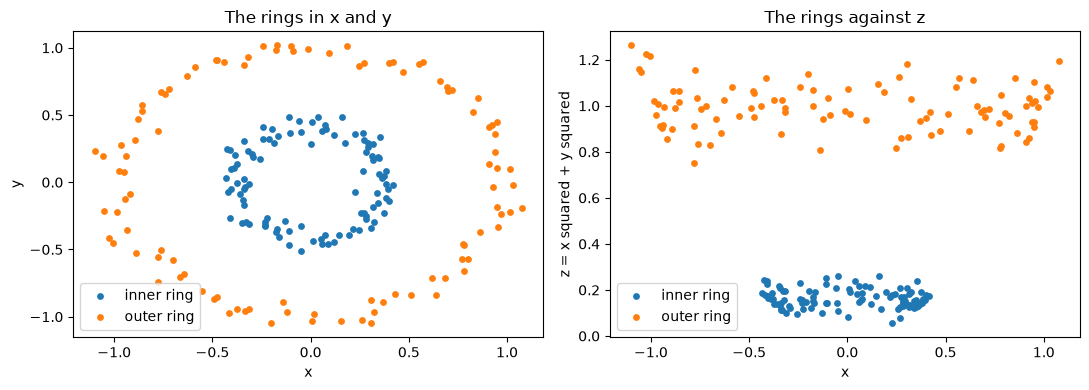

In [26]:
from sklearn.datasets import make_circles

# Made-up rings: 200 points, inner ring labelled 1, outer ring 0.
ring_points, ring_labels = make_circles(n_samples=200, factor=0.4, noise=0.05, random_state=0)

straight = SVC(kernel="linear").fit(ring_points, ring_labels)
print("straight line on x and y:     ", straight.score(ring_points, ring_labels))

squared_distance = ring_points[:, 0] ** 2 + ring_points[:, 1] ** 2
with_z = np.column_stack([ring_points, squared_distance])
straight_with_z = SVC(kernel="linear").fit(with_z, ring_labels)
print("straight cut on x, y and z:   ", straight_with_z.score(with_z, ring_labels))

curved = SVC(kernel="rbf").fit(ring_points, ring_labels)
print("RBF kernel on x and y only:   ", curved.score(ring_points, ring_labels))

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, name in [(1, "inner ring"), (0, "outer ring")]:
    chosen = ring_labels == label
    axes[0].scatter(ring_points[chosen, 0], ring_points[chosen, 1], s=15, label=name)
    axes[1].scatter(ring_points[chosen, 0], squared_distance[chosen], s=15, label=name)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("The rings in x and y")
axes[0].legend()
axes[1].set_xlabel("x")
axes[1].set_ylabel("z = x squared + y squared")
axes[1].set_title("The rings against z")
axes[1].legend()
plt.tight_layout()
plt.show()

These scores are on the same points the model learned from, so they show
whether a boundary *exists*, not how well it would do on new points.

The **kernel** is what lets the SVM do this without us building $z$. A kernel
$K(\vec x, \vec x')$ measures how similar two points are. The SVM's
calculation only ever needs those similarities, and certain kernels give
exactly the similarity the points would have after being moved into more
dimensions. So the SVM acts as if the extra columns were there, without ever
making them. That is the **kernel trick**.

## Slides 42-43: the line and the margin in symbols

A **hard margin** needs groups that can be separated: no point may sit inside
the margin. A **soft margin** (slide 39 above) allows it, at a cost set by `C`.

The line is

$$\vec w \cdot \vec x - b = 0$$

and the two dashed edges are $\vec w \cdot \vec x - b = +1$ and $-1$. The
margin between them has width $\dfrac{2}{\lVert \vec w \rVert}$, so making
$\lVert \vec w \rVert$ small makes the margin wide.

scikit-learn writes the line as $\vec w \cdot \vec x + \text{intercept} = 0$,
so the slide's $b$ is minus scikit-learn's intercept.

**Before running:** the slide 37 model is still in memory. Is its margin wider,
narrower, or the same? Compare it with the distance between the two nearest
opposite points.

In [27]:
w = model.coef_[0]
b = -model.intercept_[0]
print("w:", w.round(4), "  b:", round(b, 4))
print("margin width 2/|w|:", round(2 / np.linalg.norm(w), 4))

nearest = np.inf
for star in points[labels == 1]:
    for dot in points[labels == -1]:
        nearest = min(nearest, np.linalg.norm(star - dot))
print("distance between the two nearest opposite points:", round(nearest, 4))

w: [-0.2462  0.4308]   b: 1.1846
margin width 2/|w|: 4.0311
distance between the two nearest opposite points: 4.0311


The margin can never be wider than the gap between the closest star and the
closest dot, because both sit on or outside the margin. Here the two support
vectors face each other straight across the gap, so the two numbers match.

## Slide 44: the soft-margin score, worked by hand

The soft-margin SVM chooses $\vec w$ and $b$ to make this as small as possible:

$$\frac{1}{n}\sum_{i=1}^{n} \max\left(0,\; 1 - y_i(\vec w \cdot \vec x_i - b)\right) + \lambda \lVert \vec w \rVert^2$$

The first part is the **hinge loss**. For each point:

- safely on the right side, beyond the margin: loss 0;
- on the right side but inside the margin: a small loss;
- on the wrong side: a bigger loss, growing with the distance.

The second part, $\lambda \lVert \vec w \rVert^2$, rewards a wide margin.

Three made-up stars ($y = +1$), with a made-up line $\vec w = (1, 1)$ and
$b = 3$. **Before running:** which of the three points has zero loss?

In [28]:
w_example = np.array([1.0, 1.0])
b_example = 3.0
three_points = np.array([[3.0, 3.0], [2.0, 1.5], [1.0, 1.0]])
three_labels = np.array([1, 1, 1])

losses = []
for point, label in zip(three_points, three_labels):
    score = label * (w_example @ point - b_example)
    loss = max(0.0, 1 - score)
    losses.append(loss)
    print(f"point {point}: y(w.x - b) = {score:5.2f}  hinge loss = {loss:.2f}")

penalty_weight = 0.1                       # the slide's lambda, made up here
total = np.mean(losses) + penalty_weight * (w_example @ w_example)
print("average hinge loss:", round(np.mean(losses), 4))
print("adding 0.1 x |w| squared gives:", round(total, 4))

point [3. 3.]: y(w.x - b) =  3.00  hinge loss = 0.00
point [2.  1.5]: y(w.x - b) =  0.50  hinge loss = 0.50
point [1. 1.]: y(w.x - b) = -1.00  hinge loss = 2.00
average hinge loss: 0.8333
adding 0.1 x |w| squared gives: 1.0333


## Slide 45: common kernels

| kernel | similarity $K(\vec x, \vec x')$ | shape of boundary |
|---|---|---|
| linear | $\vec x \cdot \vec x'$ | straight |
| polynomial | $(\gamma\, \vec x \cdot \vec x' + r)^d$ | curves up to degree $d$ ($r$ is the constant term) |
| RBF (Gaussian) | $e^{-\gamma \lVert \vec x - \vec x' \rVert^2}$ | smooth blobs |
| sigmoid | $\tanh(\gamma\, \vec x \cdot \vec x' + r)$ | similar to a neural-network unit |

## Slides 46-47: limits and uses

- An SVM gives a class, not a chance. scikit-learn can add chances
  (`probability=True`), estimated by an extra step.
- The basic SVM splits two classes. scikit-learn handles more by training one
  SVM for every pair of classes.
- With a curved kernel, the weights are hard to explain in plain words.
- Uses listed on slide 47: text, images, handwriting, proteins.

In [29]:
from sklearn import svm
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Real flowers: 150 irises, 4 measurements each (cm), 3 species.
iris = load_iris()

# Keep 30% of the flowers aside as test data the model never sees.
X, Xtest, y, ytest = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=0, stratify=iris.target
)

# Create SVM classification object (note: SVC in capitals)
model = svm.SVC(kernel="rbf", C=1, gamma=1)

# Train model
model.fit(X, y)

# Evaluate quality of fit
print("score on learning data:", round(model.score(X, y), 3))
print("score on test data:    ", round(model.score(Xtest, ytest), 3))

# Predict output for test data
predicted = model.predict(Xtest)
print("first five predicted:", iris.target_names[predicted[:5]])
print("first five real:     ", iris.target_names[ytest[:5]])

score on learning data: 0.99
score on test data:     1.0
first five predicted: ['virginica' 'virginica' 'setosa' 'setosa' 'versicolor']
first five real:      ['virginica' 'virginica' 'setosa' 'setosa' 'versicolor']


In [30]:
for gamma in [0.01, 1, 100]:
    model = svm.SVC(kernel="rbf", C=1, gamma=gamma)
    model.fit(X, y)
    print(f"gamma = {gamma:<5} learning score {model.score(X, y):.3f}   test score {model.score(Xtest, ytest):.3f}")

gamma = 0.01  learning score 0.933   test score 0.956
gamma = 1     learning score 0.990   test score 1.000
gamma = 100   learning score 1.000   test score 0.600


w = [1.294 0.824] | b = 3.788
margin width 2/||w|| = 1.304 cm
[1.9 0.4] -> w.x - b = -1.0
[3.  1.1] -> w.x - b = 1.0


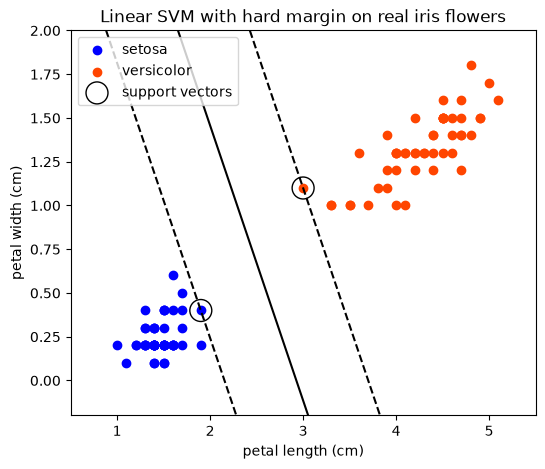

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC

# Real flowers: 50 setosa and 50 versicolor, measured in cm.
iris = load_iris()
keep = iris.target < 2                      # 0 = setosa, 1 = versicolor
X = iris.data[keep][:, [2, 3]]              # petal length, petal width
y = iris.target[keep]

# A huge C means "no point may break the margin" -> a hard margin.
svm = SVC(kernel="linear", C=1e6)
svm.fit(X, y)

w = svm.coef_[0]
b = -svm.intercept_[0]                      # scikit-learn writes w.x + b; the slide writes w.x - b
print("w =", w.round(3), "| b =", round(b, 3))
print("margin width 2/||w|| =", round(2 / np.linalg.norm(w), 3), "cm")

# Each support vector should sit exactly on a dashed line: w.x - b = -1 or +1.
for point in svm.support_vectors_:
    print(point, "-> w.x - b =", round(point @ w - b, 3))

# Draw the three lines w.x - b = -1, 0, +1 over a grid.
xx, yy = np.meshgrid(np.linspace(0.5, 5.5, 200), np.linspace(-0.2, 2, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
z = (grid @ w - b).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="blue", label="setosa")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="orangered", label="versicolor")
plt.contour(xx, yy, z, levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"])
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=250, facecolors="none", edgecolors="black", label="support vectors")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Linear SVM with hard margin on real iris flowers")
plt.legend()
plt.show()

straight line on x, y: 0.59
straight line on x, z: 1.0
RBF kernel on x, y:    1.0


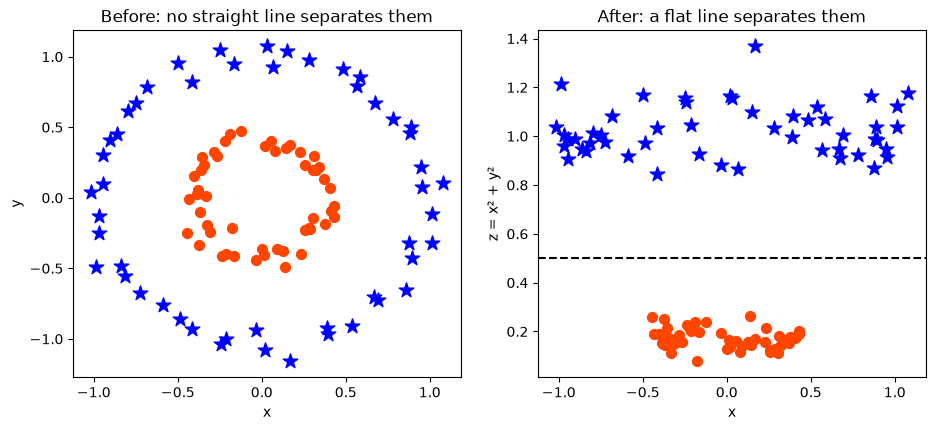

In [32]:
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles

# Made-up points: an inner ring (dots, 1) inside an outer ring (stars, 0).
points, labels = make_circles(n_samples=100, factor=0.4, noise=0.05, random_state=0)
x = points[:, 0]
y = points[:, 1]
dot = labels == 1
star = labels == 0

# 1. A straight line on x and y fails.
line = svm.SVC(kernel="linear").fit(points, labels)
print("straight line on x, y:", line.score(points, labels))

# 2. Make the new feature from the slide: z = x² + y²
z = x ** 2 + y ** 2

# 3. A straight line on x and z works. zip pairs each x with its z.
line_z = svm.SVC(kernel="linear").fit(list(zip(x, z)), labels)
print("straight line on x, z:", line_z.score(list(zip(x, z)), labels))

# 4. The RBF kernel does the transforming for us, on plain x and y.
curved = svm.SVC(kernel="rbf").fit(points, labels)
print("RBF kernel on x, y:   ", curved.score(points, labels))

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(x[star], y[star], marker="*", s=120, color="blue")
axes[0].scatter(x[dot], y[dot], s=50, color="orangered")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Before: no straight line separates them")

axes[1].scatter(x[star], z[star], marker="*", s=120, color="blue")
axes[1].scatter(x[dot], z[dot], s=50, color="orangered")
axes[1].axhline(0.5, color="black", linestyle="--")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z = x² + y²")
axes[1].set_title("After: a flat line separates them")
plt.show()

## Slide 48: an SVM on the Auckland weather

SVMs measure distances, so a column with big numbers (sun energy, up to the 30s)
would drown one with small numbers (rain, often 0). **Scaling** puts every
column on the same footing: subtract the column's mean, divide by its spread.

The mean and spread come from the **learning days only**. The test days are
scaled with those same numbers, as if we did not yet know them.

- `C`: how much each mistake on the learning days costs (bigger C, fewer
  mistakes allowed, narrower margin).
- `gamma`: how far one point's influence reaches with the RBF kernel (bigger
  gamma, shorter reach, wigglier boundary).

**Before running:** will the SVM beat logistic regression from Part 1 on
recall?

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(learn[FEATURES])               # learning days only
learn_scaled = scaler.transform(learn[FEATURES])
test_scaled = scaler.transform(test[FEATURES])

svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(learn_scaled, learn["wet_tomorrow"])
svm_predictions = svm.predict(test_scaled)

print(confusion_table(test["wet_tomorrow"], svm_predictions))
print()
print("accuracy: ", round(accuracy_score(test["wet_tomorrow"], svm_predictions), 3))
print("precision:", round(precision_score(test["wet_tomorrow"], svm_predictions), 3))
print("recall:   ", round(recall_score(test["wet_tomorrow"], svm_predictions), 3))

            predicted wet  predicted dry
really wet            286            476
really dry            119            832

accuracy:  0.653
precision: 0.706
recall:    0.375


The scores are on the test days, which the model never saw. Scoring a model
on the days it learned from would flatter it.

## Slide 49: Lab 5.3

Lab 5.3 (SVMs on linear and nonlinear problems) runs in the Saturday lab
session.

## Slide 50: strengths and weaknesses of SVMs

- **Strength:** picks the widest-gap line, which depends only on the support
  vectors.
- **Strength:** kernels let it draw curved boundaries without building new
  columns.
- **Strength:** `C` controls how much it bends to odd points.
- **Weakness:** `C` and `gamma` must be chosen; slide 48 used the defaults.
- **Weakness:** the scaler is an extra step to get right: it must be fitted on
  the learning days only.

*End of Part 2.*

# Part 3 — slides 51-68

Run this cell first. It loads the same weather, the same learn and test days,
and the `confusion_table` helper.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

FEATURES = ["tmax", "tmin", "rain", "wind", "sun"]

weather = pd.read_csv("../data/auckland-daily.csv", parse_dates=["time"])

# Tomorrow counts as wet if it gets at least 1 mm of rain.
# shift(-1) moves each day's rain up one row, so this row sees tomorrow's rain.
weather["wet_tomorrow"] = (weather["rain"].shift(-1) >= 1.0).astype(int)
weather = weather.iloc[:-1]          # the last day has no tomorrow, so drop it

# Learn from the earlier years, test on the later ones. Never shuffle weather.
learn = weather[weather["time"] < "2022-01-01"]
test = weather[weather["time"] >= "2022-01-01"]
print("days to learn from:", len(learn), "| days to test on:", len(test))


def confusion_table(actual, predicted):
    """Count the four kinds of result and lay them out with clear labels."""
    true_positive = 0
    false_positive = 0
    false_negative = 0
    true_negative = 0
    for real, guess in zip(actual, predicted):
        if real == 1 and guess == 1:
            true_positive += 1
        elif real == 0 and guess == 1:
            false_positive += 1
        elif real == 1 and guess == 0:
            false_negative += 1
        else:
            true_negative += 1
    return pd.DataFrame(
        [[true_positive, false_negative], [false_positive, true_negative]],
        index=["really wet", "really dry"],
        columns=["predicted wet", "predicted dry"],
    )

numpy 2.5.3 | pandas 3.0.3 | scikit-learn 1.9.1
days to learn from: 2557 | days to test on: 1713


## Slide 51: Bayesian inference

This part is about updating what we believe when new evidence arrives, and
then a classifier built on that idea.

## Slides 52-53: two meanings of "probability"

**Frequentist:** probability is the share of times something happens if we
repeat it many, many times. We estimate it from the sample in front of us, and
from nothing else.

**Bayesian:** probability is a **degree of belief**. We start with what we
already believed, the **prior**, and update it with the new sample. The prior
can come from earlier data, from expert knowledge, or it can be deliberately
vague. It does not need any cause-and-effect link to the thing we are
measuring; it only needs to describe what we believed beforehand.

A made-up example: ten flips of a coin. **Before running:** a frequentist
estimate of the chance of heads uses only these ten flips. What will it be?

In [35]:
# Ten made-up coin flips. 1 = heads, 0 = tails.
flips = [1, 0, 1, 1, 0, 1, 1, 0, 1, 1]

heads = 0
for flip in flips:
    heads += flip

print("heads:", heads, "out of", len(flips))
print("frequentist estimate of the chance of heads:", heads / len(flips))

heads: 7 out of 10
frequentist estimate of the chance of heads: 0.7


Most of us would still believe a normal coin is close to fair. The Bayesian
approach puts that belief into the calculation instead of ignoring it. Slide 62
shows how, with coin flips.

## Slides 54-55: Bayes' theorem

For two events $A$ and $B$:

$$p(A \mid B) = \frac{p(A)\; p(B \mid A)}{p(B)}$$

Each piece has a name:

| piece | name | in words |
|---|---|---|
| $p(A)$ | **prior** | what we believed about $A$ before seeing $B$ |
| $p(B \mid A)$ | **likelihood** | how likely the evidence $B$ is if $A$ is true |
| $p(B)$ | **evidence** | how likely $B$ is overall |
| $p(A \mid B)$ | **posterior** | what we believe about $A$ after seeing $B$ |

$p(A)$ and $p(B)$ are **marginal** probabilities. $p(A \mid B)$ and
$p(B \mid A)$ are **conditional** probabilities: they are about one event
*given* the other. Notice that $p(A \mid B)$ and $p(B \mid A)$ are different
things. Mixing them up is a very common mistake with Bayes, as the next
example shows.

## Slides 56-58: a disease test

The numbers are the slide's own (an imaginary disease and test):

- 20% of people have the disease;
- the test catches 90% of sick people (its **sensitivity**, the recall of
  Part 1);
- the test wrongly says "positive" for 30% of healthy people (its **false
  positive rate**).

Imagine 100 people. 20 are sick and 80 are healthy.

**Before running:** someone tests positive. What is the chance they really
are sick? Commit to a number first.

In [36]:
# Build the 100 imaginary people from the slide's numbers.
people = []
for number in range(20):
    # the first 18 of the 20 sick people test positive (90% of 20)
    people.append({"sick": True, "positive": number < 18})
for number in range(80):
    # the first 24 of the 80 healthy people test positive (30% of 80)
    people.append({"sick": False, "positive": number < 24})

positives = 0
sick_and_positive = 0
for person in people:
    if person["positive"]:
        positives += 1
        if person["sick"]:
            sick_and_positive += 1

print("people who test positive:", positives)
print("of those, really sick:   ", sick_and_positive)
print("chance of being sick, given a positive test, by counting:", round(sick_and_positive / positives, 4))

people who test positive: 42
of those, really sick:    18
chance of being sick, given a positive test, by counting: 0.4286


In [37]:
# Look at a few people, then count.
print(people[0])     # first sick person
print(people[19])    # last sick person tested negative
print(people[20])    # first healthy person
print(people[99])    # last healthy person
print("how many people:", len(people))
print(people[17]) #is a sick person who tests positive:

{'sick': True, 'positive': True}
{'sick': True, 'positive': False}
{'sick': False, 'positive': True}
{'sick': False, 'positive': False}
how many people: 100
{'sick': True, 'positive': True}


Now the same answer from Bayes' theorem, with $A$ = sick and $B$ = tests
positive:

$$p(\text{sick} \mid +) = \frac{p(\text{sick})\; p(+ \mid \text{sick})}{p(+)}$$

The evidence $p(+)$ adds up both ways of testing positive:

$$p(+) = p(\text{sick})\,p(+ \mid \text{sick}) + p(\text{healthy})\,p(+ \mid \text{healthy})$$

In [38]:
p_sick = 0.20                 # 20% of people are sick         -> the prior
p_positive_if_sick = 0.90     # sick people who test positive  -> p(+ | sick)
p_positive_if_healthy = 0.30  # healthy people who test positive -> p(+ | healthy)

p_positive = p_sick * p_positive_if_sick + (1 - p_sick) * p_positive_if_healthy
p_sick_if_positive = (p_sick * p_positive_if_sick) / p_positive

print("p(+), the evidence:  ", round(p_positive, 4))
print("p(sick | +), by Bayes:", round(p_sick_if_positive, 4))
assert abs(p_sick_if_positive - sick_and_positive / positives) < 1e-12

p(+), the evidence:   0.42
p(sick | +), by Bayes: 0.4286


Both routes give the same answer, and it is well below the 90% sensitivity.
The test is good at spotting sick people, but healthy people far outnumber
sick ones, so the false alarms among the healthy add up to more than the true
positives. The prior (only 20% are sick) matters a great deal.

## Slide 59: Bayesian modelling

- **Model-based:** we write down what we believe as a distribution, and the
  data updates it. The result is a whole distribution of believable values,
  not a single number.
- **The Naive Bayes assumption** (used from slide 64): *within each class*,
  the features are independent of each other. For example, among wet days,
  knowing it was windy tells you nothing extra about whether it was cloudy.
- **The prior** is rarely known exactly, so we choose a type of distribution
  (from domain knowledge, or one with convenient maths) and set its numbers
  from earlier data or judgement.

## Slide 60: kinds of prior

| kind | where it comes from | effect |
|---|---|---|
| informative, empirical | data from earlier, related studies | pulls the answer towards past results |
| informative, non-empirical | a preference, such as "coefficients should be small" | the same idea as ridge regression in Module 4 |
| informative, domain knowledge | expert knowledge with no data | pulls the answer towards what experts expect |
| non-informative | deliberately vague | the current data decides almost everything |

## Slide 61: the Beta distribution

To describe a belief about a **proportion** (a click rate, a chance of heads),
we need a distribution that lives between 0 and 1. The Beta distribution does:

$$f(x) = \frac{x^{\alpha - 1}(1 - x)^{\beta - 1}}{B(\alpha, \beta)}, \qquad 0 \le x \le 1,\quad \alpha, \beta > 0$$

$B(\alpha, \beta)$ is the beta function. It only rescales the curve so the
area under it is 1.

Its average and spread:

$$\mu = \frac{\alpha}{\alpha + \beta}
\qquad
\sigma = \sqrt{\frac{\alpha\beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}}$$

**Before running:** which pair of $\alpha, \beta$ on the slide gives a curve
that is high at both ends and low in the middle?

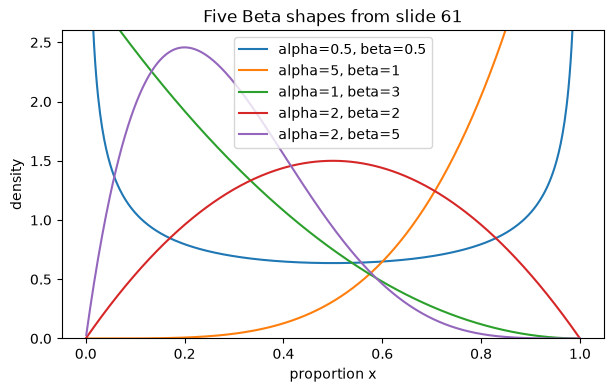

alpha=0.5  beta=0.5  mean 0.500  sd 0.354
alpha=5    beta=1    mean 0.833  sd 0.141
alpha=1    beta=3    mean 0.250  sd 0.194
alpha=2    beta=2    mean 0.500  sd 0.224
alpha=2    beta=5    mean 0.286  sd 0.160


In [39]:
from scipy import stats

pairs = [(0.5, 0.5), (5, 1), (1, 3), (2, 2), (2, 5)]
x_values = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(7, 4))
for alpha, beta in pairs:
    plt.plot(x_values, stats.beta(alpha, beta).pdf(x_values), label=f"alpha={alpha}, beta={beta}")
plt.ylim(0, 2.6)
plt.xlabel("proportion x")
plt.ylabel("density")
plt.title("Five Beta shapes from slide 61")
plt.legend()
plt.show()

for alpha, beta in pairs:
    mean_by_formula = alpha / (alpha + beta)
    sd_by_formula = np.sqrt(alpha * beta / ((alpha + beta) ** 2 * (alpha + beta + 1)))
    assert abs(mean_by_formula - stats.beta(alpha, beta).mean()) < 1e-12
    assert abs(sd_by_formula - stats.beta(alpha, beta).std()) < 1e-12
    print(f"alpha={alpha:<4} beta={beta:<4} mean {mean_by_formula:.3f}  sd {sd_by_formula:.3f}")

## Slide 62: updating a belief about a coin

Before any flips we know nothing, so every chance of heads is equally
believable. That flat belief is **Beta(1, 1)**.

The rule for updating is just adding counts:

$$\text{Beta}(1 + \text{heads},\; 1 + \text{tails})$$

**Before running:** as the flips pile up, what happens to the width of the curve?

  0 flips: Beta(1, 1), average 0.500, width (sd) 0.289
 10 flips: Beta(9, 3), average 0.750, width (sd) 0.120
500 flips: Beta(233, 269), average 0.464, width (sd) 0.022


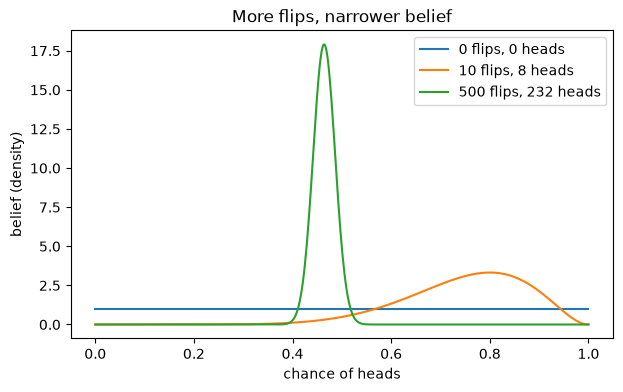

In [40]:
from scipy import stats

x_values = np.linspace(0, 1, 500)
plt.figure(figsize=(7, 4))

# (flips, heads): no flips yet, then 10 flips, then 500 flips
for flips, heads in [(0, 0), (10, 8), (500, 232)]:
    tails = flips - heads
    belief = stats.beta(1 + heads, 1 + tails)      # start flat, add the counts
    plt.plot(x_values, belief.pdf(x_values), label=f"{flips} flips, {heads} heads")
    print(f"{flips:3} flips: Beta({1 + heads}, {1 + tails}), average {belief.mean():.3f}, width (sd) {belief.std():.3f}")

plt.xlabel("chance of heads")
plt.ylabel("belief (density)")
plt.title("More flips, narrower belief")
plt.legend()
plt.show()

### From coins to weather

Treat each learning day as one flip: **wet tomorrow = heads, dry tomorrow
= tails**. The same rule gives our belief about the chance that any day is
followed by a wet one. That belief is the **prior** p(wet) that Naive Bayes
starts from. Naive Bayes then updates it with each day's weather and picks
the likelier answer.

In [41]:
from sklearn.naive_bayes import GaussianNB

# Each learning day is one "flip": wet tomorrow = heads, dry tomorrow = tails.
wet_days = learn["wet_tomorrow"].sum()
dry_days = len(learn) - wet_days
print("learning days:", len(learn), "| wet tomorrow:", wet_days, "| dry tomorrow:", dry_days)

belief_wet = stats.beta(1 + wet_days, 1 + dry_days)
print(f"Beta({1 + wet_days}, {1 + dry_days}): average {belief_wet.mean():.3f}, width (sd) {belief_wet.std():.3f}")

# GaussianNB starts from the same number as its prior p(wet).
bayes = GaussianNB()
bayes.fit(learn[FEATURES], learn["wet_tomorrow"])
print("GaussianNB's prior p(wet):", round(bayes.class_prior_[1], 3))

# Then it updates the prior with each day's weather and picks the likelier class.
print(confusion_table(test["wet_tomorrow"], bayes.predict(test[FEATURES])))

learning days: 2557 | wet tomorrow: 1008 | dry tomorrow: 1549
Beta(1009, 1550): average 0.394, width (sd) 0.010
GaussianNB's prior p(wet): 0.394
            predicted wet  predicted dry
really wet            213            549
really dry             83            868


## Slide 66: three kinds of Naive Bayes in scikit-learn

They differ in what they assume about each feature **within a class**:

| class in `sklearn.naive_bayes` | features | assumes |
|---|---|---|
| `GaussianNB` | numbers | each feature is bell-shaped (normal) within each class |
| `BernoulliNB` | yes/no | each feature is a yes/no switch; uses smoothing |
| `MultinomialNB` | counts, such as word counts | counts follow a multinomial distribution; uses smoothing |

Only `GaussianNB` assumes normal features. Our weather columns are numbers,
so we use it.




---

*Data Science and AI, Module 5. Weather data from
[Open-Meteo](https://open-meteo.com/), licensed CC BY 4.0.*